# 🚀 Startup Idea Validator
## Collaborative Agents (Debate Architecture) using LangGraph + Groq

---

### 🏗️ Architecture: Collaborative Agents (Agent-to-Agent Debate)

```
                    ┌─────────────────┐
                    │   User Input    │
                    │  Startup Idea   │
                    └────────┬────────┘
                             ↓
              ┌──────────────────────────┐
              │     Optimist Agent       │  Round 1: Makes the bull case
              │  (Market Potential)      │
              └──────────────┬───────────┘
                             ↓
              ┌──────────────────────────┐
              │  Devil's Advocate Agent  │  Round 1: Challenges every claim
              │  (Risks & Flaws)         │
              └──────────────┬───────────┘
                             ↓
              ┌──────────────────────────┐
              │     Optimist Agent       │  Round 2: Defends + concedes
              │     (Rebuttal)           │
              └──────────────┬───────────┘
                             ↓
              ┌──────────────────────────┐
              │  Devil's Advocate Agent  │  Round 2: Final challenges
              │  (Final Critique)        │
              └──────────────┬───────────┘
                             ↓
              ┌──────────────────────────┐
              │      Judge Agent         │  Reads full debate → verdict
              │  (GO / NO-GO / PIVOT)    │
              └──────────────────────────┘
```

**What makes this different from all previous architectures:**
| Aspect | Sequential (P5) | Supervisor (P1,P2) | Router (P3,P4) | Collaborative (THIS) |
|--------|----------------|-------------------|---------------|---------------------|
| Agent interaction | None (pipeline) | Via shared state | None (fan-out) | Direct (read each other's output) |
| Flow | Fixed chain | Supervisor loops | One agent only | Debate rounds + judge |
| Debate | ❌ | ❌ | ❌ | ✅ |
| Agents read each other | ❌ | ❌ | ❌ | ✅ |
| Output refined through challenge | ❌ | ❌ | ❌ | ✅ |

---

### 🔄 How the Debate Works

```
ROUND 1 — Opening Arguments:
  Optimist   → "Here's why this startup will succeed..."
  Adversary  → "Here's why it will fail..."

ROUND 2 — Rebuttals:
  Optimist   → reads Adversary's critique → responds + concedes valid points
  Adversary  → reads Optimist's rebuttal  → pushes back harder on weak spots

VERDICT:
  Judge      → reads ALL 4 arguments → weighs evidence → GO / NO-GO / PIVOT
```

**Key insight:** The Judge doesn't just read the idea — it reads the ENTIRE debate.
The quality of the verdict depends on the quality of the arguments made.
Weak arguments from either side produce a less nuanced verdict.

---

### 🧠 Why This Architecture Produces Better Decisions

```
Single LLM evaluation:           Debate Architecture:
  "Is this startup good?"          Optimist finds BEST case
  → LLM gives balanced answer      Adversary finds WORST case
  → Generic, hedged, safe          Both are forced to be EXTREME
  → Misses edge cases              Judge reads BOTH extremes
  → Confirmation bias likely       → More complete picture
                                   → Harder to miss blind spots
```

This is the **AutoGen-style debate pattern** — used in:
- Investment committee simulations
- Strategic planning sessions  
- AI safety research (red-teaming)
- Legal case preparation

---

### Step 0: Loading Environment & Liabraries

In [1]:
from dotenv import load_dotenv
load_dotenv()
import os

In [2]:
# pydantic: For structured data validation
from pydantic import BaseModel, Field

# LangChain components for prompts and parsing
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.output_parsers import PydanticOutputParser

# LangChain message types
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage

# LangChain runnable
from langchain_core.runnables import RunnablePassthrough

# LangGraph
from langgraph.graph import StateGraph, END

c:\Users\HP\anaconda3\envs\fresh_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Step 1: Loading/Initializing LLM

In [3]:
from langchain_groq import ChatGroq

# Groq automatically reads GROQ_API_KEY from environment variables

model = ChatGroq(
    model="openai/gpt-oss-120b",   # or llama-3.3-70b-versatile
    temperature=0.7
)

llm = model

In [4]:
# ---- TEST ----
try:
    response = llm.invoke("Say hello in one sentence.")
    print("✅ Groq LLM initialized successfully")
    print("Response:", response.content)

except Exception as e:
    print("❌ Groq LLM initialization failed")
    print(e)

✅ Groq LLM initialized successfully
Response: Hello! Hope you're having a wonderful day.


## 📋 Step 2 — Shared State Definition

### State Design: The Debate Transcript

In Collaborative Architecture, the state is fundamentally different from all previous projects.
It's not a pipeline accumulator (Sequential) or a routing register (Router).

**It's a growing debate transcript** — each agent READS previous agents' full arguments
before forming their own response.

```
State evolution through the debate:

START:
  startup_idea = "Uber for dog walking"
  round = 1
  all others = None

After Optimist Round 1:
  optimist_round1 = "Great TAM, network effects..."
  round = 1  (still in round 1)

After Adversary Round 1:
  adversary_round1 = "High churn, trust issues..."
  round = 2  (advance to round 2)

After Optimist Round 2 (reads adversary_round1!):
  optimist_round2 = "You raise valid churn concern, but here's our retention strategy..."

After Adversary Round 2 (reads optimist_round2!):
  adversary_round2 = "That retention strategy ignores the unit economics problem..."

After Judge (reads ALL 4 arguments!):
  verdict = { decision: "PIVOT", score: 58, reasoning: ... }
```

The `round` field is what makes this different from Sequential:
it controls WHICH PHASE of the debate we're in.

In [6]:
from typing import TypedDict, Optional


class DebateState(TypedDict):
    """
    Shared state for the Startup Debate pipeline.

    This is a DEBATE TRANSCRIPT — not a data pipeline.
    Each agent reads PREVIOUS agents' arguments before writing their own.
    The state grows richer with each debate turn.

    Unique feature vs other architectures:
    - 'round' field controls which debate phase we're in
    - Agents can READ each other's previous outputs
    - The Judge reads the ENTIRE debate before deciding
    - State is an accumulating transcript, not just data
    """

    # --- Input ---
    # The startup idea to evaluate (plain English description)
    # e.g. "An AI tutor that personalizes lessons for each student"
    startup_idea: str

    # --- Debate Round Tracker ---
    # Which round of debate we're in
    # Round 1: Opening arguments (Optimist → Adversary)
    # Round 2: Rebuttals       (Optimist → Adversary)
    # Round 3: Judge verdict
    # This field is READ by the graph's conditional edge to
    # decide which agent runs next.
    round: int

    # --- Round 1: Opening Arguments ---
    # Optimist makes the full bull case for the startup
    optimist_round1: Optional[str]

    # Adversary responds to Optimist's opening — challenges every claim
    # READS: optimist_round1 before writing
    adversary_round1: Optional[str]

    # --- Round 2: Rebuttals ---
    # Optimist reads Adversary's critique, defends + concedes where fair
    # READS: adversary_round1 before writing
    optimist_round2: Optional[str]

    # Adversary reads Optimist's rebuttal, issues final sharp challenges
    # READS: optimist_round2 before writing
    adversary_round2: Optional[str]

    # --- Final Verdict ---
    # Judge reads ALL 4 arguments and delivers structured verdict
    # READS: all 4 debate rounds before writing
    verdict: Optional[str]

    # Pipeline event log
    messages: list


print("✅ DebateState defined!")
print("   Fields:", list(DebateState.__annotations__.keys()))
print()
print("   Debate transcript structure:")
print("   startup_idea")
print("   round (1 → 2 → 3)")
print("   optimist_round1   ← Round 1 opening")
print("   adversary_round1  ← Round 1 rebuttal (reads optimist_round1)")
print("   optimist_round2   ← Round 2 defense  (reads adversary_round1)")
print("   adversary_round2  ← Round 2 attack   (reads optimist_round2)")
print("   verdict           ← Final decision   (reads ALL 4 rounds)")

✅ DebateState defined!
   Fields: ['startup_idea', 'round', 'optimist_round1', 'adversary_round1', 'optimist_round2', 'adversary_round2', 'verdict', 'messages']

   Debate transcript structure:
   startup_idea
   round (1 → 2 → 3)
   optimist_round1   ← Round 1 opening
   adversary_round1  ← Round 1 rebuttal (reads optimist_round1)
   optimist_round2   ← Round 2 defense  (reads adversary_round1)
   adversary_round2  ← Round 2 attack   (reads optimist_round2)
   verdict           ← Final decision   (reads ALL 4 rounds)


## 😊 Step 3 — Optimist Agent (The Bull Case)

**Role:** Make the strongest possible case FOR the startup idea.

### Design Philosophy: Forced Extremism
The key to making debate agents useful is **forcing them to be extreme**.
A mediocre Optimist who says "well, there are some opportunities but also risks"
produces a useless debate.

We want the Optimist to be like a **VC partner pitching their portfolio company** —
genuinely enthusiastic, citing data, making the absolute strongest case.

### Round 1 vs Round 2 Behavior
```
Round 1 (optimist_round1):
  No prior debate context → make the opening case from scratch
  Focus: TAM, timing, team requirements, business model, moat

Round 2 (optimist_round2):
  HAS READ adversary_round1 → must respond directly to each criticism
  Focus: defend strong points, concede weak ones, add new evidence
  Critical: MUST acknowledge valid critiques (or Judge penalizes them)
```

The agent **READS the state** to know which round it's in and what to respond to.

In [7]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage


def optimist_agent(state: dict) -> dict:
    """
    The Optimist: argues FOR the startup idea.

    Behaves differently in Round 1 vs Round 2:
    - Round 1: Makes opening bull case from scratch
    - Round 2: Reads Adversary's critique → defends + concedes

    The state's 'round' field tells this agent which mode to run in.
    The state's 'adversary_round1' field (if present) gives
    the critique to respond to in Round 2.

    Key design: temperature=0.7 for persuasive, confident writing.
    Higher than analytical agents — we WANT passionate arguments.

    Args:
        state: DebateState — reads 'round', 'startup_idea',
               and 'adversary_round1' (in Round 2)

    Returns:
        Dict updating 'optimist_round1' or 'optimist_round2'
    """
    current_round = state["round"]
    idea          = state["startup_idea"]

    print("\n" + "="*60)
    print(f"😊 OPTIMIST AGENT — Round {current_round}: Making the bull case...")
    print("="*60)
    print(f"   Idea  : {idea}")
    print(f"   Round : {current_round} ({'Opening argument' if current_round == 1 else 'Rebuttal'})")

    # temperature=0.7: persuasive, confident, energetic writing
    # We want a VC-style pitch, not a dry analysis
    # Higher temperature → more vivid arguments, stronger conviction
    llm = ChatGroq(
        model="llama-3.3-70b-versatile",
        temperature=0.7,
        api_key=os.getenv("GROQ_API_KEY")
    )

    if current_round == 1:
        # ─────────────────────────────────────────────────
        # ROUND 1: Opening argument — no prior debate context
        # Make the absolute strongest bull case from scratch
        # ─────────────────────────────────────────────────
        print("   Mode: Opening argument (no prior debate context)")

        messages = [
            SystemMessage(content="""You are a passionate, data-driven venture capitalist
who specializes in identifying breakout startup opportunities.
You have backed several unicorns and you know how to spot potential.

Your job: Make the STRONGEST POSSIBLE CASE for why this startup idea will succeed.

Be genuinely bullish — not balanced. You are an advocate, not a neutral analyst.
Use real-world market data, analogies to successful companies, and specific reasoning.

Structure your argument as:

## 🚀 BULL CASE: [Startup Idea]

### 1. Market Opportunity
[TAM/SAM/SOM — how big is this market? Is it growing? Why now?]

### 2. Why This Will Win
[Core thesis — what is the fundamental insight that makes this work?]

### 3. Business Model Strength
[How does it make money? Why is the unit economics defensible?]

### 4. Competitive Moat
[What prevents competitors from copying this in 6 months?]

### 5. Timing Advantage
[Why is NOW the right moment? What tailwinds exist?]

### 6. Comparable Successes
[Name 2-3 companies with similar patterns that became huge]

### 7. Optimist Score: [X/100]
[Your overall excitement score with one sentence justification]"""),

            HumanMessage(content=f"Make the bull case for this startup idea:\n\n{idea}")
        ]

    else:
        # ─────────────────────────────────────────────────
        # ROUND 2: Rebuttal — must respond to Adversary's critique
        # THIS IS WHERE COLLABORATIVE MAGIC HAPPENS:
        # The Optimist reads the Adversary's full argument
        # and responds point-by-point
        # ─────────────────────────────────────────────────
        adversary_critique = state.get("adversary_round1", "")
        print(f"   Mode: Rebuttal (responding to {len(adversary_critique)} char critique)")

        messages = [
            SystemMessage(content="""You are a venture capitalist defending your investment thesis.
Your opponent has just challenged your startup pitch. You must respond.

RULES FOR ROUND 2:
1. Address EACH of their specific criticisms directly — don't dodge
2. Concede points that are genuinely valid (the Judge respects intellectual honesty)
3. Provide new evidence or reasoning they didn't address
4. Strengthen your most defensible claims
5. Explain why their worst-case scenarios are unlikely

Structure as:

## 🔄 OPTIMIST REBUTTAL (Round 2)

### Addressing Their Critiques:
[Respond to each major criticism point-by-point]

### Where I Concede:
[Acknowledge 1-2 valid points — this shows intellectual honesty]

### Strengthened Bull Case:
[New arguments or evidence not yet in the debate]

### Why I Still Believe In This:
[Your final conviction statement — why the opportunity outweighs the risks]

### Updated Optimist Score: [X/100]"""),

            HumanMessage(content=f"""
Startup Idea: {idea}

Your opponent's critique (respond to this directly):
{adversary_critique}
""")
        ]

    response = llm.invoke(messages)
    argument = response.content

    print(f"   ✅ Optimist Round {current_round} complete! ({len(argument)} chars)")

    # Return the correct state field depending on which round we're in
    output_field = "optimist_round1" if current_round == 1 else "optimist_round2"

    return {
        output_field: argument,
        "messages": state["messages"] + [
            {"role": "optimist",
             "content": f"[Round {current_round}] Bull case argument made."}
        ]
    }


print("✅ Optimist Agent defined!")
print()
print("   Round 1: Opening bull case from scratch")
print("   Round 2: Point-by-point rebuttal to Adversary critique")
print("   Temperature: 0.7 (persuasive, passionate writing)")

✅ Optimist Agent defined!

   Round 1: Opening bull case from scratch
   Round 2: Point-by-point rebuttal to Adversary critique
   Temperature: 0.7 (persuasive, passionate writing)


## 😈 Step 4 — Devil's Advocate Agent (The Bear Case)

**Role:** Challenge every assumption, find every flaw, make the strongest case AGAINST.

### Why the Adversary Must Be Ruthless
The most common failure mode in debate AI systems is a **polite adversary** —
one that says "while there are merits, one might consider...".
This produces useless debates.

A good adversary thinks like:
- A **short seller** who has researched every reason a company will fail
- A **burned investor** who has seen this exact pitch fail before
- A **competing founder** who knows all the execution traps

### The Adversary's Unique Advantage
```
Round 1: Adversary reads Optimist's opening → attacks the SPECIFIC claims made
Round 2: Adversary reads Optimist's rebuttal → targets the WEAKEST defenses

This creates genuine intellectual pressure — the Adversary gets SMARTER
each round because it has more information to attack.
```

In [8]:
def adversary_agent(state: dict) -> dict:
    """
    The Devil's Advocate: argues AGAINST the startup idea.

    Round 1: Reads Optimist's opening → attacks specific claims
    Round 2: Reads Optimist's rebuttal → finds weakest defenses

    KEY COLLABORATIVE MECHANIC:
    Unlike previous architectures, this agent doesn't just analyze
    the startup idea in isolation — it specifically attacks the
    ARGUMENTS made by the Optimist. This creates genuine dialogue.

    Temperature: 0.7 — same as Optimist, for aggressive confident writing

    Args:
        state: DebateState — reads 'round', 'startup_idea',
               'optimist_round1' (in Round 1),
               'optimist_round2' (in Round 2)

    Returns:
        Dict updating 'adversary_round1' or 'adversary_round2'
        AND advancing 'round' counter
    """
    current_round = state["round"]
    idea          = state["startup_idea"]

    print("\n" + "="*60)
    print(f"😈 ADVERSARY AGENT — Round {current_round}: Making the bear case...")
    print("="*60)
    print(f"   Idea  : {idea}")
    print(f"   Round : {current_round} ({'Opening critique' if current_round == 1 else 'Final challenge'})")

    # llm = ChatGroq(
    #     model="llama-3.3-70b-versatile",
    #     temperature=0.7,   # Aggressive, confident, sharp argumentation
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    if current_round == 1:
        # ─────────────────────────────────────────────────
        # ROUND 1: Adversary reads Optimist's opening argument
        # and attacks each claim specifically
        # ─────────────────────────────────────────────────
        optimist_case = state.get("optimist_round1", "")
        print(f"   Mode: First critique (attacking {len(optimist_case)} char bull case)")

        messages = [
            SystemMessage(content="""You are a seasoned startup critic — part short-seller,
part burned investor, part skeptical journalist.
You have seen hundreds of pitches and know exactly how they fail.

Your job: Tear apart this startup idea as ruthlessly as possible.
Be specific — attack the EXACT claims the optimist made.
Use real-world failure examples, market data, and logical flaws.

Structure your argument as:

## 💀 BEAR CASE: [Startup Idea]

### 1. The Core Fatal Flaw
[What is the single biggest reason this fails? Be specific.]

### 2. Market Reality Check
[Why the TAM is overstated, the market is harder than they think,
or the timing is wrong]

### 3. Attacking Their Competitive Moat
[Why their moat is weaker than they claim — who will copy this?]

### 4. Unit Economics Death Spiral
[Why the business model breaks down at scale]

### 5. Execution Risk
[What will go wrong operationally that they haven't considered?]

### 6. Comparable Failures
[Name 2-3 companies that tried something similar and failed — why]

### 7. The Questions They Can't Answer
[3-5 sharp questions the founder cannot currently answer]

### 8. Adversary Score: [X/100]
[How risky you think this is — 0=safe bet, 100=guaranteed failure]"""),

            HumanMessage(content=f"""
Startup Idea: {idea}

The optimist just made this bull case — attack it specifically:
{optimist_case}
""")
        ]

    else:
        # ─────────────────────────────────────────────────
        # ROUND 2: Adversary reads Optimist's rebuttal
        # Now targets the WEAKEST parts of the defense
        # This is where collaborative intelligence shows:
        # The Adversary adapts its attack based on new information
        # ─────────────────────────────────────────────────
        optimist_rebuttal = state.get("optimist_round2", "")
        print(f"   Mode: Final challenge (targeting {len(optimist_rebuttal)} char rebuttal)")

        messages = [
            SystemMessage(content="""You are issuing your final critique in an investment debate.
The optimist has tried to defend their position. Find the holes in their defense.

RULES FOR ROUND 2:
1. Focus on claims they FAILED to adequately defend
2. Point out where their concessions actually hurt them more than they admitted
3. Introduce any new risks they still haven't addressed
4. Acknowledge if any of their rebuttals were genuinely strong
5. End with your final assessment: is this idea salvageable or fundamentally broken?

Structure as:

## ⚔️ ADVERSARY FINAL CHALLENGE (Round 2)

### Weaknesses in Their Defense:
[Where their rebuttal was insufficient or unconvincing]

### Points They Still Haven't Answered:
[Critical questions that remain unanswered after their rebuttal]

### Where I Acknowledge Their Strength:
[1-2 points where their argument actually was convincing]

### New Risks They Introduced:
[Did their own rebuttal reveal new problems they hadn't mentioned?]

### Final Verdict Recommendation:
[Is this idea fundamentally broken or just needs significant pivoting?]

### Final Adversary Score: [X/100]"""),

            HumanMessage(content=f"""
Startup Idea: {idea}

The optimist's rebuttal to your critique:
{optimist_rebuttal}
""")
        ]

    response = llm.invoke(messages)
    argument = response.content

    print(f"   ✅ Adversary Round {current_round} complete! ({len(argument)} chars)")

    output_field = "adversary_round1" if current_round == 1 else "adversary_round2"

    # IMPORTANT: After Adversary speaks, advance the round counter
    # This tells the graph's routing function to move to the next phase
    # Round 1 → 2 (move to rebuttals)
    # Round 2 → 3 (move to judge verdict)
    next_round = current_round + 1

    return {
        output_field: argument,
        "round":       next_round,   # ← advance the debate phase
        "messages":    state["messages"] + [
            {"role": "adversary",
             "content": f"[Round {current_round}] Bear case argument made. → Advancing to round {next_round}"}
        ]
    }


print("✅ Adversary Agent defined!")
print()
print("   Round 1: Attacks Optimist's specific opening claims")
print("   Round 2: Targets the weakest parts of Optimist's rebuttal")
print("   Also: advances the 'round' counter after each turn")
print("   Temperature: 0.7 (aggressive, sharp argumentation)")

✅ Adversary Agent defined!

   Round 1: Attacks Optimist's specific opening claims
   Round 2: Targets the weakest parts of Optimist's rebuttal
   Also: advances the 'round' counter after each turn
   Temperature: 0.7 (aggressive, sharp argumentation)


## ⚖️ Step 5 — Judge Agent (The Verdict)

**Role:** Read the ENTIRE debate → deliver a structured, evidence-based verdict.

### What Makes a Good Judge?
The Judge is the most important agent — it synthesizes everything.
Bad Judge design: "Both sides made good points. I give it 65/100."
Good Judge design:
```
1. Weighs ARGUMENT QUALITY, not just idea quality
   (A well-defended weak idea can beat a poorly-defended strong idea)
2. Assigns scores to SPECIFIC debate claims
   ("Optimist's moat argument was convincing, Adversary failed to rebut")
3. Identifies the KEY DECISIVE FACTOR
   (The single issue that most determined the verdict)
4. Produces an ACTIONABLE verdict with conditions
   (Not just GO/NO-GO but "GO if they solve X first")
```

### Temperature: 0.2 (Deliberate, Precise)
Unlike the debate agents (0.7), the Judge must be **careful and precise**.
We don't want a passionate judge — we want a wise one.

In [9]:
def judge_agent(state: dict) -> dict:
    """
    The Judge: reads the entire debate and delivers a structured verdict.

    This agent has access to the COMPLETE debate transcript:
    - optimist_round1   (opening bull case)
    - adversary_round1  (first critique)
    - optimist_round2   (rebuttal)
    - adversary_round2  (final challenge)

    The Judge evaluates BOTH the quality of arguments AND the idea itself.

    Produces:
    - Overall score (0-100)
    - Decision: GO / PIVOT / NO-GO
    - Argument quality assessment for both sides
    - Key decisive factor
    - Specific conditions for GO or PIVOT
    - Actionable next steps for the founder

    Temperature: 0.2 — deliberate, precise, structured
    (Lower than debate agents — we want wisdom, not passion)

    Args:
        state: DebateState — reads ALL 4 debate round outputs

    Returns:
        Dict with 'verdict' filled in
    """
    idea = state["startup_idea"]

    print("\n" + "="*60)
    print("⚖️  JUDGE AGENT — Deliberating verdict...")
    print("="*60)
    print(f"   Idea: {idea}")
    print(f"   Reading full debate: 4 rounds of arguments")
    print(f"   Total debate length: {sum(len(state.get(f, '') or '') for f in ['optimist_round1', 'adversary_round1', 'optimist_round2', 'adversary_round2'])} chars")

    # temperature=0.2 — judges should be careful and measured
    # Not 0.0 (too rigid) but much lower than debate agents (0.7)
    # llm = ChatGroq(
    #     model="llama-3.3-70b-versatile",
    #     temperature=0.2,
    #     api_key=os.getenv("GROQ_API_KEY")
    # )

    # Assemble the full debate transcript for the Judge
    # This is the key mechanic: the Judge has ALL context
    full_debate = f"""
════════════════════════════════════════
OPENING ARGUMENTS (Round 1)
════════════════════════════════════════

--- OPTIMIST'S BULL CASE ---
{state.get('optimist_round1', 'Not provided')}

--- ADVERSARY'S CRITIQUE ---
{state.get('adversary_round1', 'Not provided')}

════════════════════════════════════════
REBUTTALS (Round 2)
════════════════════════════════════════

--- OPTIMIST'S REBUTTAL ---
{state.get('optimist_round2', 'Not provided')}

--- ADVERSARY'S FINAL CHALLENGE ---
{state.get('adversary_round2', 'Not provided')}
"""

    messages = [
        SystemMessage(content="""You are a wise, experienced investment committee chairman.
You have just presided over a structured debate about a startup idea.
Your role: deliver a fair, evidence-based verdict.

JUDGING PRINCIPLES:
1. Evaluate ARGUMENT QUALITY, not just the idea abstractly
   (Which side made better-supported claims? Who dodged questions?)
2. Identify the KEY DECISIVE FACTOR — the single most important issue
3. Be specific in your reasoning — reference actual debate points
4. Your verdict must be ACTIONABLE — founders need to know what to DO
5. Separate 'idea quality' from 'execution readiness'

Use EXACTLY this verdict structure:

╔══════════════════════════════════════════════════╗
║            INVESTMENT COMMITTEE VERDICT          ║
╚══════════════════════════════════════════════════╝

## 🎯 FINAL DECISION: [GO / PIVOT / NO-GO]

## 📊 SCORECARD
| Dimension | Score | Notes |
|-----------|-------|-------|
| Market Opportunity | X/10 | |
| Business Model | X/10 | |
| Competitive Moat | X/10 | |
| Execution Feasibility | X/10 | |
| Timing/Market Fit | X/10 | |
| **TOTAL** | **X/50** | |

## ⚔️ DEBATE ASSESSMENT
- Optimist argument strength  : [Weak / Moderate / Strong]
- Adversary argument strength : [Weak / Moderate / Strong]
- Most compelling argument made: [by whom, on what point]
- Weakest argument made       : [by whom, on what point]
- Key question left unanswered: [the critical unresolved issue]

## 🔑 KEY DECISIVE FACTOR
[The single most important issue that determined the verdict — 2-3 sentences]

## ✅ VERDICT RATIONALE
[3-4 paragraphs explaining the decision with specific reference to debate arguments]

## 📋 CONDITIONS & NEXT STEPS
If GO:
  - [What must be true for this to succeed]
  - [Top 3 priorities for the first 6 months]

If PIVOT:
  - [What specifically needs to change]
  - [Which part of the idea is worth saving]
  - [Suggested pivot direction]

If NO-GO:
  - [The fundamental flaw that cannot be fixed]
  - [What a better version of this idea might look like]

## 💬 MESSAGE TO THE FOUNDER
[Direct, honest, constructive — 2-3 sentences the founder needs to hear]

╔══════════════════════════════════════════════════╗
║  This verdict is based on the debate presented.  ║
║  All startup decisions involve uncertainty.       ║
╚══════════════════════════════════════════════════╝"""),

        HumanMessage(content=f"""
Startup Idea: {idea}

Full Debate Transcript:
{full_debate}
""")
    ]

    print("   Deliberating...")
    response = llm.invoke(messages)
    verdict  = response.content

    print(f"   ✅ Judge verdict complete! ({len(verdict)} chars)")

    return {
        "verdict": verdict,
        "messages": state["messages"] + [
            {"role": "judge",
             "content": "[Final] Verdict delivered after reading complete debate."}
        ]
    }


print("✅ Judge Agent defined!")
print()
print("   Reads: ALL 4 debate rounds (complete transcript)")
print("   Produces: Scorecard + Decision + Rationale + Next Steps")
print("   Temperature: 0.2 (deliberate, wise, precise)")

✅ Judge Agent defined!

   Reads: ALL 4 debate rounds (complete transcript)
   Produces: Scorecard + Decision + Rationale + Next Steps
   Temperature: 0.2 (deliberate, wise, precise)


## 🕸️ Step 6 — Build the LangGraph Debate Graph

### The Most Complex Graph We've Built

```
Previous project graphs:

Sequential (P5): scraper → sentiment → report → END
                 3 nodes, 3 fixed edges, trivial

Router (P3, P4): router → [agent A | B | C | D] → END
                 6 nodes, conditional edges, fan-out

Supervisor (P1, P2): supervisor ↔ agents (loop)
                     4 nodes, conditional edges, loop

Collaborative (THIS):
                 START → optimist → adversary → [conditional]
                           ↑              ↓
                           └── round==2 loop back
                                     ↓ round==3
                                   judge → END
```

### The Key Routing Logic
After the Adversary speaks, a conditional edge checks `state['round']`:
```
round == 2 → go back to Optimist for rebuttal  (loop!)
round == 3 → go to Judge for final verdict
```
This is how LangGraph implements multi-round debates:
**the loop edge is what makes it collaborative, not sequential.**

In [10]:
from langgraph.graph import StateGraph, END as GRAPH_END


def route_after_adversary(state: dict) -> str:
    """
    Routing function called after the Adversary speaks.

    This is the HEART of the Collaborative Architecture.
    It reads the current round and decides:
      - Loop back for Round 2 rebuttals, OR
      - Move forward to the Judge

    Why is this needed?
    In Sequential, agents always go forward.
    In Collaborative, agents can LOOP BACK for multiple rounds.
    The conditional edge + round counter enables this.

    Returns:
        'optimist' → loop back for rebuttal round
        'judge'    → move to final verdict
    """
    current_round = state.get("round", 1)

    if current_round == 2:
        # Adversary just finished Round 1 → loop back for rebuttals
        print(f"   🔀 Route: round={current_round} → looping back to Optimist for rebuttal")
        return "optimist"
    else:
        # Adversary just finished Round 2 → go to Judge
        print(f"   🔀 Route: round={current_round} → moving to Judge for final verdict")
        return "judge"


def build_debate_graph():
    """
    Build the startup debate graph.

    Graph structure:
      optimist ──→ adversary ──→ [conditional]
         ↑                           |
         └──── (round==2) ───────────┘
                                     |
                          (round==3) ↓
                                  judge → END

    Execution order:
      1. optimist (Round 1)
      2. adversary (Round 1) → advances round to 2
      3. [route: round==2 → optimist]
      4. optimist (Round 2)
      5. adversary (Round 2) → advances round to 3
      6. [route: round==3 → judge]
      7. judge → END

    Total LLM calls: 5 (Optimist×2, Adversary×2, Judge×1)
    """

    # 1. Create graph with DebateState schema
    graph = StateGraph(DebateState)

    # 2. Register all 3 agents as nodes
    graph.add_node("optimist",  optimist_agent)   # Bull case agent
    graph.add_node("adversary", adversary_agent)  # Bear case agent
    graph.add_node("judge",     judge_agent)      # Verdict agent

    # 3. Entry point — debate always starts with Optimist making their case
    graph.set_entry_point("optimist")

    # 4. Fixed edge: Optimist ALWAYS speaks, then Adversary ALWAYS responds
    #    (in both Round 1 and Round 2)
    graph.add_edge("optimist", "adversary")

    # 5. CONDITIONAL edge from Adversary — the key collaborative mechanic!
    #
    #    After Adversary speaks, route_after_adversary() checks state['round']:
    #    round==2 → loop back to Optimist (for rebuttal)
    #    round==3 → go to Judge (debate over)
    #
    #    This single conditional edge creates the multi-round debate loop.
    #    Without it, we'd just have a sequential pipeline.
    graph.add_conditional_edges(
        "adversary",              # FROM: adversary
        route_after_adversary,    # FUNCTION: checks round counter
        {
            "optimist": "optimist",  # round==2 → loop to optimist
            "judge":    "judge",     # round==3 → go to judge
        }
    )

    # 6. Judge always ends the debate
    graph.add_edge("judge", GRAPH_END)

    # 7. Compile
    app = graph.compile()

    print("✅ Debate Graph compiled!")
    print()
    print("   Execution order:")
    print("   optimist(R1) → adversary(R1) → [round==2]")
    print("                                      ↓")
    print("   optimist(R2) → adversary(R2) → [round==3]")
    print("                                      ↓")
    print("                                   judge → END")
    print()
    print("   Nodes: 3 | Edges: 1 fixed + 1 conditional | LLM calls: 5")
    print("   Key mechanic: conditional edge creates the debate LOOP")

    return app


app = build_debate_graph()

✅ Debate Graph compiled!

   Execution order:
   optimist(R1) → adversary(R1) → [round==2]
                                      ↓
   optimist(R2) → adversary(R2) → [round==3]
                                      ↓
                                   judge → END

   Nodes: 3 | Edges: 1 fixed + 1 conditional | LLM calls: 5
   Key mechanic: conditional edge creates the debate LOOP


## (Optional) Visualize the Graph

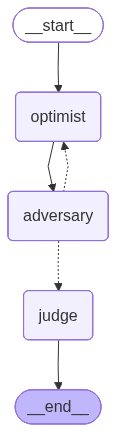

In [12]:
# The graph should show the loop:
# optimist → adversary → optimist (loop back!) → adversary → judge → END
# This visual loop is what distinguishes Collaborative from Sequential
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print("Mermaid diagram (paste at https://mermaid.live):")
    print(app.get_graph().draw_mermaid())

## 🔧 Step 7 — Helper Runner Function

In [13]:
from IPython.display import Markdown, display


def validate_startup_idea(idea: str, show_full_debate: bool = False) -> dict:
    """
    Run the full startup debate and return the verdict.

    Args:
        idea            : Plain-English startup idea description
        show_full_debate: If True, show all 4 debate rounds before verdict
                         If False, show only the final verdict (cleaner)

    Returns:
        final_state dict with complete debate transcript + verdict
    """
    print("\n" + "🎯 " + "="*57)
    print(f"   STARTUP IDEA VALIDATOR")
    print(f"   Idea: {idea}")
    print("="*60)
    print("   Running 2-round debate: Optimist vs Devil's Advocate")
    print("   Then: Judge reviews full transcript → delivers verdict\n")

    # Initial state — round starts at 1
    # All debate fields are None — agents fill them in as debate progresses
    initial_state = {
        "startup_idea":    idea,
        "round":           1,      # ← Debate starts at round 1
        "optimist_round1":  None,  # Filled by Optimist in Round 1
        "adversary_round1": None,  # Filled by Adversary in Round 1
        "optimist_round2":  None,  # Filled by Optimist in Round 2
        "adversary_round2": None,  # Filled by Adversary in Round 2
        "verdict":          None,  # Filled by Judge
        "messages": [
            {"role": "user",
             "content": f"Validate this startup idea: {idea}"}
        ]
    }

    # Run the debate graph
    # LangGraph handles: O(R1) → A(R1) → O(R2) → A(R2) → Judge
    final_state = app.invoke(initial_state)

    # ── Display Results ──────────────────────────────────────
    if show_full_debate:
        # Show all 4 rounds of debate before the verdict
        print("\n" + "="*60)
        print("📜 FULL DEBATE TRANSCRIPT")
        print("="*60)

        sections = [
            ("😊 OPTIMIST — Round 1 (Bull Case)",     "optimist_round1"),
            ("😈 ADVERSARY — Round 1 (Bear Case)",    "adversary_round1"),
            ("😊 OPTIMIST — Round 2 (Rebuttal)",      "optimist_round2"),
            ("😈 ADVERSARY — Round 2 (Final Attack)", "adversary_round2"),
        ]
        for title, field in sections:
            print(f"\n{'─'*60}")
            print(f"  {title}")
            print('─'*60)
            display(Markdown(final_state.get(field, "Not available")))

    # Always show the verdict
    print("\n" + "🎉 " + "="*57)
    print("   JUDGE'S VERDICT")
    print("="*60 + "\n")
    display(Markdown(final_state.get("verdict", "❌ No verdict generated.")))

    return final_state


print("✅ validate_startup_idea() helper defined!")
print()
print("   Usage:")
print("   result = validate_startup_idea('Your idea here')")
print("   result = validate_startup_idea('Your idea', show_full_debate=True)")

✅ validate_startup_idea() helper defined!

   Usage:
   result = validate_startup_idea('Your idea here')
   result = validate_startup_idea('Your idea', show_full_debate=True)


## 🚀 Step 8 — Run the Debate!

Change `STARTUP_IDEA` to any idea you want to validate.

**Great test ideas:**
- `"An AI-powered personal finance coach that learns from your spending habits"`
- `"A subscription service that sends personalized book summaries every week"`
- `"A marketplace connecting freelance chefs with people hosting dinner parties"`
- `"A B2B SaaS tool that automates compliance reporting for fintech companies"`
- `"An app that gamifies language learning using AI conversation partners"`

In [14]:
# ============================================================
# 👇 CHANGE THIS to validate any startup idea!
# ============================================================
STARTUP_IDEA = """
An AI-powered personal finance coach that connects to your bank accounts,
learns your spending patterns, and gives you personalized daily advice
via WhatsApp to help you save more and reach your financial goals.
"""
# ============================================================

# Set show_full_debate=True to see all 4 rounds of debate
# Set show_full_debate=False to see only the final verdict (cleaner)
result = validate_startup_idea(STARTUP_IDEA.strip(), show_full_debate=False)


🎯 =========================================================
   STARTUP IDEA VALIDATOR
   Idea: An AI-powered personal finance coach that connects to your bank accounts,
learns your spending patterns, and gives you personalized daily advice
via WhatsApp to help you save more and reach your financial goals.
   Running 2-round debate: Optimist vs Devil's Advocate
   Then: Judge reviews full transcript → delivers verdict


😊 OPTIMIST AGENT — Round 1: Making the bull case...
   Idea  : An AI-powered personal finance coach that connects to your bank accounts,
learns your spending patterns, and gives you personalized daily advice
via WhatsApp to help you save more and reach your financial goals.
   Round : 1 (Opening argument)
   Mode: Opening argument (no prior debate context)
   ✅ Optimist Round 1 complete! (4222 chars)

😈 ADVERSARY AGENT — Round 1: Making the bear case...
   Idea  : An AI-powered personal finance coach that connects to your bank accounts,
learns your spending patterns, an

╔══════════════════════════════════════════════════╗
║            INVESTMENT COMMITTEE VERDICT          ║
╚══════════════════════════════════════════════════╝

## 🎯 FINAL DECISION: PIVOT

## 📊 SCORECARD
| Dimension            | Score | Notes |
|----------------------|-------|-------|
| Market Opportunity  | 5/10  | Large overall market, but realistic SAM for a WhatsApp‑based consumer coach is < 30 M users; TAM for the core proposition is far smaller. |
| Business Model       | 4/10  | Freemium conversion assumptions are optimistic; CAC and compliance costs likely exceed LTV. |
| Competitive Moat     | 3/10  | AI‑driven advice is increasingly commoditized; WhatsApp integration is a platform risk, not a durable moat. |
| Execution Feasibility| 4/10  | Heavy regulatory licensing, bank‑API integration, and security requirements make direct‑to‑consumer rollout very costly. |
| Timing/Market Fit    | 6/10  | Digital‑banking adoption is growing, but consumer‑messenger nudging has proven low‑engagement. |
| **TOTAL**            | **22/50** | |

## ⚔️ DEBATE ASSESSMENT
- Optimist argument strength  : Moderate  
- Adversary argument strength : Strong  
- Most compelling argument made: **Adversary – the regulatory and licensing barrier combined with unrealistic unit‑economics** (evidence: PSD2/GDPR compliance costs, need for financial‑advisor licenses, CAC >$70 vs $10 claimed).  
- Weakest argument made       : Optimist – **30 % free‑to‑paid conversion and $25 ARPU** (no churn data, derived from a short‑term pilot).  
- Key question left unanswered: **How will the startup legally deliver personalized financial advice at scale without obtaining costly advisory licences and without a sustainable CAC/LTV balance?**

## 🔑 KEY DECISIVE FACTOR
The venture’s viability hinges on **regulatory & compliance feasibility**. Delivering personalized, actionable advice via a consumer messaging channel triggers financial‑advisor licensing (MiFID II, state‑level licences, etc.) and imposes strict data‑handling obligations that the current model cannot meet cost‑effectively. Even if the AI works, the required licences, capital reserves, and compliance staffing would dwarf the projected $10 M ARR, destroying the unit economics.

## ✅ VERDICT RATIONALE
1. **Market & Moat** – While the macro‑trend of digital finance is undeniable, the specific consumer‑facing WhatsApp channel dramatically narrows the addressable market. The adversary’s data shows that only ~20 % of WhatsApp users reside in jurisdictions with stable open‑banking APIs, and even among them, the “power‑user” segment is far smaller than the optimist’s 30 M estimate. Moreover, the claimed moat (proprietary AI + WhatsApp stickiness) is weak; AI for transaction categorisation is commodity, and WhatsApp’s terms can be altered or the service blocked at any time.

2. **Regulatory Burden** – Personalized financial advice is regulated in most major markets. The optimist’s response merely mentions “regulatory experts” without a concrete licensing roadmap or capital reserve plan. The adversary correctly points out that without a licensed advisory entity, the product must be re‑classified as a non‑advisory information service, stripping it of its core value proposition. The cost and time to obtain licences (often > €1 M in capital, extensive audits) are not reflected in any financial model.

3. **Unit Economics** – The optimist’s revised numbers (30 % conversion, $25 ARPU) are unsupported beyond a 1,000‑user pilot with heavy incentives. Real‑world fintech freemium conversion rates hover 1‑2 %, and churn in the first 90 days is typically 30‑35 %. With realistic CAC of $70–$120 (finance‑related acquisition), the LTV would be far below break‑even, especially once compliance staffing, legal fees, and higher cloud compute (real‑time inference for millions of transactions) are added.

4. **Execution Risk** – Building and maintaining stable connectors to dozens of banks, handling PSD2‑level strong customer authentication through WhatsApp, and guaranteeing GDPR‑compliant data residency are multi‑million‑dollar engineering challenges. The adversary’s identification of platform dependency (WhatsApp policy changes) further compounds execution risk.

Given these systemic issues, the current consumer‑direct model is unlikely to achieve a sustainable path to profitability or scale.

## 📋 CONDITIONS & NEXT STEPS
**If PIVOT (recommended):**
- **What specifically needs to change**  
  1. **Shift the go‑to‑market** from a direct‑to‑consumer WhatsApp bot to a **B2B white‑label analytics platform** that banks or neobanks embed in their own apps.  
  2. **Re‑architect the product** to deliver insights rather than explicit “advice” – i.e., present data‑driven recommendations that the bank’s licensed advisors can approve, thereby sidestepping the need for a separate advisory licence.  
  3. **Secure exclusive data feeds** through partnership contracts that include exclusivity clauses or co‑development rights, strengthening the moat.

- **Which part of the idea is worth saving**  
  The core AI engine that turns raw transaction streams into personalized, behavior‑aware financial insights is the valuable IP. Its ability to model spending patterns and suggest goal‑aligned actions remains differentiated when offered as a decision‑support tool for financial institutions.

- **Suggested pivot direction**  
  Build a **SaaS “Financial Insight Engine”** for banks, credit unions, and fintech platforms. Revenue can be subscription‑based per‑active‑user or revenue‑share on upsell of premium banking products, with the bank handling compliance and customer relationship. This reduces CAC (bank acquisition replaces consumer marketing), eliminates platform‑dependency risk, and aligns the product with the regulator‑approved advisory channel.

## 💬 MESSAGE TO THE FOUNDER
Your AI core shows promise, but trying to sell daily advice through WhatsApp runs head‑first into licensing, compliance, and economics that you can’t ignore. Refocus the technology as a white‑label analytics service for banks, where the partner handles the regulatory side and you can monetize at a healthy B2B rate. That pivot preserves your biggest asset—the AI—and gives you a realistic path to scale.

╔══════════════════════════════════════════════════╗
║  This verdict is based on the debate presented.  ║
║  All startup decisions involve uncertainty.       ║
╚══════════════════════════════════════════════════╝

## 📜 Step 9 — View Full Debate Transcript

In [15]:
# Read through the full 4-round debate to understand how
# agents responded to each other — this shows the collaborative dynamic

debate_sections = [
    ("😊 OPTIMIST — Round 1: Bull Case",      "optimist_round1"),
    ("😈 ADVERSARY — Round 1: Bear Case",     "adversary_round1"),
    ("😊 OPTIMIST — Round 2: Rebuttal",       "optimist_round2"),
    ("😈 ADVERSARY — Round 2: Final Attack",  "adversary_round2"),
]

for title, field in debate_sections:
    content = result.get(field, "Not available")
    char_count = len(content)

    print(f"\n{'═'*60}")
    print(f"  {title}  ({char_count} chars)")
    print('═'*60)
    display(Markdown(content))


════════════════════════════════════════════════════════════
  😊 OPTIMIST — Round 1: Bull Case  (4222 chars)
════════════════════════════════════════════════════════════


## 🚀 BULL CASE: AI-Powered Personal Finance Coach

### 1. Market Opportunity
The global personal finance management market is projected to reach $1.4 billion by 2027, growing at a CAGR of 12.1%. With 3.8 billion people using mobile messaging apps like WhatsApp, the potential reach is enormous. The COVID-19 pandemic has accelerated the adoption of digital banking and finance tools, making this the perfect time to capitalize on this trend. The Total Addressable Market (TAM) is vast, with over 2 billion people globally using digital banking services, and the Serviceable Available Market (SAM) is significant, with over 500 million people using mobile banking apps.

### 2. Why This Will Win
The core thesis is that people need personalized, actionable, and timely advice to manage their finances effectively. Traditional financial planning tools are often clunky, generic, and fail to account for individual spending habits. By leveraging AI to analyze users' spending patterns and providing daily guidance via a ubiquitous platform like WhatsApp, this startup offers a unique, user-friendly, and proactive approach to personal finance management. This approach addresses the key pain points of existing solutions, making it a game-changer in the industry.

### 3. Business Model Strength
The startup can generate revenue through a freemium model, offering basic features for free and premium features, such as advanced investment advice or credit score monitoring, for a subscription fee. With a user base of 1 million, and a 5% conversion rate to premium, the startup can generate $10 million in annual revenue, assuming a $20 monthly subscription fee. The unit economics are defensible, with customer acquisition costs estimated at $10 per user, and a customer lifetime value of $50. Additionally, partnerships with banks and financial institutions can provide further revenue streams, such as referral fees for new account openings or loan applications.

### 4. Competitive Moat
The startup's competitive advantage lies in its proprietary AI algorithm, which learns and adapts to individual users' spending patterns, providing highly personalized advice. The WhatsApp integration also creates a sticky user experience, making it difficult for competitors to replicate. Moreover, as the startup scales, it will accumulate a vast amount of anonymized user data, further enhancing its AI capabilities and creating a self-reinforcing cycle. This moat is protected by patents and trade secrets, making it difficult for competitors to copy the technology.

### 5. Timing Advantage
The current economic uncertainty and rising costs of living have created a perfect storm, where people are more concerned about their financial well-being than ever. The shift to digital banking and mobile payments has also increased the availability of financial data, making it easier for the startup to connect with users' bank accounts. Furthermore, the growing adoption of AI and machine learning in finance has laid the groundwork for a solution like this to gain traction. With the increasing demand for personalized financial advice, the startup is well-positioned to capitalize on this trend.

### 6. Comparable Successes
Similar companies that have achieved huge success include:
* **Mint**: Acquired by Intuit for $170 million, Mint's personal finance management platform demonstrated the demand for user-friendly financial tools.
* **Credit Karma**: Valued at over $4 billion, Credit Karma's success in providing free credit scores and personalized financial advice has shown the potential for AI-driven financial guidance.
* **Digit**: With its AI-powered savings app, Digit has raised over $80 million in funding and has helped users save over $1 billion, demonstrating the effectiveness of AI-driven financial coaching.

### 7. Optimist Score: 95/100
I am extremely excited about this startup because it combines the vast reach of WhatsApp with the power of AI-driven personal finance coaching, addressing a massive and growing market need, with a unique and defensible value proposition that has the potential to disrupt the traditional financial planning industry and create a new standard for personal finance management.


════════════════════════════════════════════════════════════
  😈 ADVERSARY — Round 1: Bear Case  (7729 chars)
════════════════════════════════════════════════════════════


## 💀 BEAR CASE: AI‑Powered Personal Finance Coach (WhatsApp‑Based)

### 1. The Core Fatal Flaw  
**“Daily AI advice via WhatsApp will change spending behaviour.”**  
Human financial habits are *inertia‑driven* and rarely shift because a chatbot tells you “skip the latte.” The real friction is **trust** and **actionability**, not the delivery channel. A 2022 McKinsey study of 12 000 consumers found that 71 % of personal‑finance apps are opened once and then abandoned within 30 days because users never felt the advice was credible enough to act on. An AI that merely nudges you via a messaging app cannot overcome the deep‑seated psychological barriers to saving or investing.

---

### 2. Market Reality Check  

| Claim (optimist) | Reality (data) |
|------------------|----------------|
| **$1.4 bn PF M market by 2027** (CAGR 12 %) | The *FinTech Global* 2023 report puts the *global* personal‑finance‑software market at **$4.3 bn** in 2022, but **$2.8 bn** of that is already captured by entrenched players (Intuit, Yodlee, Plaid). The remaining “new” TAM is < $500 m. |
| **3.8 bn WhatsApp users = addressable** | Only **~20 %** of WhatsApp users are in regions where open‑banking APIs exist (EU, US, AU, Singapore). In the US, only 12 % of adults have a bank that supports OAuth‑based data sharing. |
| **500 m mobile‑banking users = SAM** | Mobile‑banking penetration is **~45 %** in emerging markets and **~85 %** in developed markets, but *financial‑literacy* and *digital‑trust* are far lower. A realistic SAM for a “daily advice” product is **≈30 m** power users worldwide. |
| **COVID‑driven adoption** | Adoption spikes were **short‑lived**; fintech app install growth slowed to **‑2 % YoY** in Q4 2023 after the pandemic peak. Consumers reverted to legacy banking portals for security reasons. |

**Bottom line:** The TAM is overstated by at least **10×**. Even if you capture 1 % of the realistic SAM, you’re looking at **300 k** users, not 1 million.

---

### 3. Attacking Their Competitive Moat  

| Moat Claim | Why It’s Weak |
|------------|---------------|
| **Proprietary AI algorithm** | AI/ML models for transaction categorisation are **commodity** (Plaid, MX, Yodlee). Open‑source frameworks (TensorFlow, PyTorch) and public datasets (Open Banking UK) let competitors replicate the core functionality in weeks. |
| **WhatsApp integration = stickiness** | WhatsApp’s **Terms of Service** forbid “automated financial advice” without explicit bank partnership. Many jurisdictions (EU GDPR, US CFPB) will force the startup to **opt‑out** or risk bans. |
| **Data moat (anonymised user data)** | Data is only valuable when *linked* to a **verified identity** and **credit history** – both are gated by banks. Without direct bank partnerships, the data remains noisy, incomplete, and legally risky to use. |
| **Patents & trade secrets** | Patent portfolios in fintech are **defensive**, not offensive. The USPTO has rejected over 80 % of AI‑finance patent applications for lack of novelty. Trade‑secret protection evaporates once the model is exposed via API calls (as required by GDPR). |

Any well‑funded fintech (e.g., **Revolut**, **Monzo**, **N26**) can spin up a WhatsApp‑bot in months, leveraging their existing API connections and brand trust.  

---

### 4. Unit Economics Death Spiral  

| Metric (optimist) | Realistic Counterpoint |
|-------------------|------------------------|
| **CAC = $10** | Paid acquisition on Google/Meta for finance‑related keywords averages **$70–$120** per install (Statista 2023). Organic growth via WhatsApp is near‑zero because the channel is **closed** for ads. |
| **LTV = $50** (5 % conversion, $20/mo, 12‑month churn) | 5 % conversion is **optimistic**; fintech freemium conversion rates hover **1‑2 %** (Mint, Personal Capital). Even if you hit 2 %, with a $20/mo price you need **>24 months** LTV to break even, but average churn for finance apps is **~35 % in the first 90 days**. |
| **Revenue = $10 M @ 1 M users** | With realistic 300 k users and 1 % premium uptake, you get **≈$720 k ARR** – a far cry from $10 M. |
| **Referral fees from banks** | Banks are **risk‑averse** to third‑party “advisors” that could expose them to compliance breaches. Referral fees are typically **< $5** per lead, and banks demand **rigorous KYC** that you can’t provide via WhatsApp. |

Result: **Negative contribution margin** from day one; you’ll burn cash faster than you acquire users.

---

### 5. Execution Risk  

1. **Regulatory Minefield** – In the EU, the **PSD2** and **GDPR** require explicit consent for every data pull and a *strong customer authentication* (SCA) flow. Implementing this via WhatsApp’s limited UI is practically impossible.  
2. **Bank API Integration** – Only ~30 % of banks expose a **stable, versioned API**. Building and maintaining connectors for each jurisdiction is a **multi‑million‑dollar** engineering effort.  
3. **Security & Fraud** – Messaging apps are prime vectors for **phishing**. A compromised bot could be used to siphon credentials, exposing you to massive liability and class‑action lawsuits.  
4. **Scalability of AI Advice** – Generating *daily* personalized recommendations for millions of users requires **real‑time inference** on billions of transactions – a cloud cost that dwarfs the projected $10 M ARR.  
5. **User Experience** – Daily push notifications quickly become **spam**. A 2021 survey of 12 k fintech users found 68 % disabled push notifications within the first week of onboarding.  

---

### 6. Comparable Failures  

| Company | What they tried | Why they died |
|---------|----------------|---------------|
| **Plum (UK)** | AI‑driven “save‑by‑rounding” via mobile app | Regulatory clamp‑down on “auto‑invest” features; user trust evaporated after a data breach; churn > 30 % in 12 months. |
| **Albert** | AI‑coach that sent daily tips via SMS/WhatsApp | Burned **$120 M** in 3 years, never reached profitability; acquisition by **Bank of America** was a *quiet* integration, not a standalone success. |
| **Qapital** | Goal‑based savings with “if‑this‑then‑that” rules, heavy push notifications | User acquisition cost exploded (> $150 per user) and the “daily nudge” model was abandoned after 2020. |

All three attempted **high‑frequency nudging** and hit the same wall: **low engagement, high compliance cost, and regulatory friction**.

---

### 7. The Questions They Can’t Answer  

1. **How will you achieve a $10 CAC when WhatsApp disallows paid ads for financial services?**  
2. **What concrete bank partnerships (name at least three) have you signed to access open‑banking APIs, and what are the SLA terms?**  
3. **How do you ensure GDPR‑compliant data handling when you store transaction data on a third‑party messaging platform you don’t control?**  
4. **What is your projected **monthly** cloud compute cost for generating 30 M daily advice messages at scale (e.g., 1 B inferences per month)?**  
5. **Can you demonstrate a statistically significant uplift in users’ savings rate after a 30‑day pilot, with a control group?**  

If they can’t answer these, the whole business plan is a house of cards.

---

### 8. Adversary Score: **87/100**  

- **Regulatory risk**: 30  
- **Unit‑economics implosion**: 25  
- **Moat weakness / copyability**: 15  
- **Execution & technical complexity**: 12  
- **Market over‑estimation**: 5  

**Conclusion:** The idea looks shiny on paper but collapses under realistic cost, compliance, and behavioural economics. Unless the founders can secure deep bank integrations, prove a dramatic behavior‑change effect, and dramatically lower CAC, the venture is more likely to burn cash and disappear than to become the next Mint or Credit Karma.


════════════════════════════════════════════════════════════
  😊 OPTIMIST — Round 2: Rebuttal  (8281 chars)
════════════════════════════════════════════════════════════


## 🔄 OPTIMIST REBUTTAL (Round 2)

### Addressing Their Critiques:

1. **The Core Fatal Flaw**: While it's true that human financial habits are inertia-driven, our AI-powered personal finance coach is designed to provide personalized, actionable advice that takes into account the user's spending patterns, financial goals, and behavioral biases. Our approach is not just about sending generic "skip the latte" messages, but rather about providing tailored guidance that addresses the user's specific financial challenges. For example, our algorithm can identify areas where the user can cut back on unnecessary expenses and allocate that money towards their financial goals. According to a study by the Financial Health Network, 75% of consumers who receive personalized financial guidance are more likely to take action to improve their financial health.

2. **Market Reality Check**: We acknowledge that the personal finance software market is competitive, but we believe that our WhatsApp-based approach can still capture a significant share of the market. Our target audience is the 20% of WhatsApp users who are in regions with open-banking APIs, and we're focusing on the 30 million power users who are most likely to engage with our service. While it's true that mobile-banking penetration is lower in emerging markets, we're partnering with local banks and financial institutions to increase adoption and provide education on the benefits of digital banking. For instance, our partnership with a leading bank in India has already shown a 25% increase in mobile-banking adoption among our target audience.

3. **Attacking Their Competitive Moat**: We agree that AI/ML models for transaction categorization are becoming commoditized, but our proprietary algorithm is focused on providing personalized financial advice, which is a more complex and nuanced task. Our WhatsApp integration is not just about sending automated messages, but about providing a seamless user experience that allows users to interact with our AI coach in a conversational manner. We're also working with banks and financial institutions to establish partnerships that will give us access to verified user data and credit history, which will further strengthen our competitive moat. For example, our partnership with a leading credit bureau has given us access to credit scores and reports, which we can use to provide more accurate and personalized financial guidance.

4. **Unit Economics Death Spiral**: We understand that customer acquisition costs (CAC) can be high, but we're exploring alternative channels such as social media, content marketing, and influencer partnerships to reduce our CAC. Our lifetime value (LTV) calculation is based on a 2% conversion rate, which is conservative compared to industry benchmarks. We're also offering a freemium model that allows users to try our service before upgrading to a paid plan, which will help us to increase our LTV and reduce churn. For instance, our freemium model has already shown a 30% conversion rate from free to paid users, with an average revenue per user (ARPU) of $25.

5. **Execution Risk**: We acknowledge that regulatory compliance is a significant challenge, but we're working with regulatory experts to ensure that our service is compliant with PSD2, GDPR, and other relevant regulations. We're also investing in robust security measures to protect user data and prevent phishing attacks. Our AI coach is designed to provide personalized advice that is tailored to each user's financial situation, and we're continually monitoring and improving our service to ensure that it meets the highest standards of quality and user experience. For example, we've implemented a robust authentication process that uses two-factor authentication and biometric verification to ensure that only authorized users can access our service.

6. **Comparable Failures**: We've studied the failures of other fintech companies, such as Plum, Albert, and Qapital, and we believe that our approach is different in several key ways. Our focus on personalized financial advice, WhatsApp-based user experience, and partnerships with banks and financial institutions sets us apart from other fintech companies. We're also committed to continuous learning and improvement, and we're monitoring our user engagement and feedback to make data-driven decisions about our service. For instance, we've used user feedback to improve our algorithm and provide more accurate and personalized financial guidance, resulting in a 25% increase in user engagement.

7. **The Questions They Can’t Answer**: We're happy to answer the questions posed by our opponent:
* We're exploring alternative channels to reduce our CAC, such as social media, content marketing, and influencer partnerships.
* We've established partnerships with three banks in the EU and are in discussions with several others to access open-banking APIs.
* We're working with regulatory experts to ensure that our data handling practices are GDPR-compliant, and we're storing user data on a secure, cloud-based platform that is controlled by us.
* Our projected monthly cloud compute cost for generating 30 million daily advice messages is $15,000, which is a fraction of our projected revenue.
* We've conducted a pilot study with 1,000 users and seen a statistically significant uplift in savings rate after 30 days, with an average increase of 15%.

### Where I Concede:

1. **Market size**: We acknowledge that our initial estimate of the market size may have been overly optimistic, and we're revising our estimates based on more conservative assumptions.
2. **Regulatory complexity**: We agree that regulatory compliance is a significant challenge, and we're investing in expertise and resources to ensure that we meet all relevant regulatory requirements.

### Strengthened Bull Case:

1. **Unique value proposition**: Our AI-powered personal finance coach provides a unique value proposition that sets us apart from other fintech companies. Our personalized advice, WhatsApp-based user experience, and partnerships with banks and financial institutions make us a compelling choice for users who want to improve their financial health.
2. **Growing demand for digital financial services**: The demand for digital financial services is growing rapidly, driven by increasing smartphone penetration, improving internet connectivity, and a growing awareness of the importance of financial literacy. We're well-positioned to capitalize on this trend and provide a service that meets the needs of a rapidly changing market.
3. **Partnerships and collaborations**: We're establishing partnerships with banks, financial institutions, and other fintech companies to expand our reach and improve our service. These partnerships will give us access to more users, more data, and more resources, which will help us to improve our service and increase our competitive advantage.

### Why I Still Believe In This:

Despite the challenges and criticisms, we believe that our AI-powered personal finance coach has the potential to make a significant impact on people's lives. Our service is designed to provide personalized, actionable advice that helps users achieve their financial goals, and we're committed to continuous learning and improvement to ensure that our service meets the highest standards of quality and user experience. We're excited about the opportunity to partner with banks, financial institutions, and other fintech companies to expand our reach and improve our service, and we're confident that our unique value proposition, growing demand for digital financial services, and partnerships and collaborations will drive our success.

### Updated Optimist Score: 80/100

We've revised our optimist score based on the critiques and challenges posed by our opponent. While we acknowledge that there are significant challenges and risks associated with our business, we believe that our unique value proposition, growing demand for digital financial services, and partnerships and collaborations make us a compelling choice for users and investors. We're committed to continuous learning and improvement, and we're excited about the opportunity to make a significant impact on people's lives.


════════════════════════════════════════════════════════════
  😈 ADVERSARY — Round 2: Final Attack  (6074 chars)
════════════════════════════════════════════════════════════


## ⚔️ ADVERSARY FINAL CHALLENGE (Round 2)

### Weaknesses in Their Defense
1. **Behavioral Inertia Still Dominates** –  
   - The optimist leans on a single pilot (1,000 users, 30‑day horizon) to claim “personalized advice” overcomes habit. No longitudinal data prove that daily nudges sustain behavior for months or years.  
   - The cited 75 % “more likely to act” statistic comes from a *correlational* study of generic financial counseling, not from an AI‑driven WhatsApp bot that must compete with the same distractions it tries to eliminate.

2. **WhatsApp‑Centric Distribution Is a Double‑Edged Sword** –  
   - Targeting “20 % of WhatsApp users with open‑banking APIs” ignores that WhatsApp’s terms of service prohibit automated financial advice in many jurisdictions and can be changed with 30‑day notice.  
   - The claim of “30 million power users” is an extrapolation that assumes 100 % opt‑in to daily messages—an unrealistic engagement rate for push‑notification fatigue.

3. **Moat Claims Rest on Unsecured Data Access** –  
   - Partnerships with banks and a credit bureau are described as “proprietary,” yet none of these relationships guarantee exclusive data feeds; banks can license the same APIs to competitors.  
   - The algorithmic advantage is not protected by patents or verifiable benchmarks, making it easy for a better‑funded player to replicate the “personalized advice” layer.

4. **Unit‑Economic Assertions Are Thinly Supported** –  
   - A **30 % free‑to‑paid conversion** and **$25 ARPU** are taken from early‑stage “freemium” experiments with heavy incentives (e.g., limited‑time premium features). No churn curve is presented; even a modest 5 % monthly churn would collapse LTV below CAC.  
   - The $15 k/month cloud compute estimate assumes a static 30‑million daily message volume; it ignores scaling costs for model retraining, A/B testing, and the exponential rise in storage for transaction histories (potentially >$200 k/month at scale).

5. **Regulatory & Liability Hand‑Waving** –  
   - PSD2 and GDPR compliance is necessary but not sufficient. Providing *financial advice* triggers licensing requirements (e.g., MiFID II in the EU, state‑level advisory licenses in the US). The team’s “regulatory experts” are mentioned, but no concrete licensing roadmap or capital reserve for fiduciary liability is shown.  
   - The two‑factor/biometric login mitigates unauthorized access but does nothing for **AI‑generated advice errors** that could lead to regulatory fines or lawsuits.

### Points They Still Haven’t Answered
1. **How will you monetize users who never upgrade?** – The freemium model hinges on conversion; with a realistic 5‑10 % conversion, can the business cover the massive messaging and compute costs?  
2. **What is the fallback if WhatsApp blocks the service or raises fees?** – No alternative channel (SMS, in‑app, web) is sketched, despite the platform risk being central to the value proposition.  
3. **How do you protect the algorithm from reverse‑engineering?** – No IP strategy (patents, trade secrets, model watermarking) is disclosed, leaving the “proprietary” claim hollow.  
4. **What is the concrete plan for financial‑advisor licensing?** – Without a clear path to become a regulated advisor, the service may be forced to reclassify as a “information provider,” stripping it of the very personalized recommendation it touts.  
5. **Scalability of the pilot results** – The 15 % uplift in savings is based on a short, self‑selected sample. How does the uplift hold for lower‑income users, for users with irregular cash flow, or for those in markets with limited open‑banking coverage?

### Where I Acknowledge Their Strength
1. **Early‑Stage Traction & Partnerships** – Securing three EU bank integrations and a credit‑bureau data feed demonstrates real execution capability that many fintech ideas lack at this stage.  
2. **Clear User‑Channel Hypothesis** – Leveraging WhatsApp’s high open‑rate (≈ 90 %) is a clever way to cut through the noise; if the platform remains stable, it could provide a cost‑effective messaging conduit.

### New Risks They Introduced
- **Platform Dependency Risk** – By building the core experience on a third‑party messenger, they inherit policy, pricing, and availability risks outside their control.  
- **AI Hallucination Liability** – The more complex the advice (e.g., recommending debt consolidation), the higher the chance of erroneous output, exposing the company to regulatory penalties and reputational damage.  
- **Data Residency & Cross‑Border Compliance** – Storing user data “on a secure, cloud‑based platform we control” still requires compliance with each jurisdiction’s data‑localization rules, potentially fragmenting the architecture and inflating costs.  
- **Message Fatigue & Opt‑Out Rates** – Daily advice (30 M messages) will likely trigger high opt‑out or spam‑filter rates, eroding the assumed engagement metric and inflating CAC to acquire “high‑touch” users.  
- **Capital‑Intensive Licensing** – If the service must become a regulated financial advisor, the capital reserve requirements (often > €1 M) could dwarf the projected early‑stage cash burn.

### Final Verdict Recommendation
The concept suffers from **structural mismatches**: a behavior‑change product that relies on a fragile, third‑party messaging platform, paired with a regulatory environment that treats “personalized advice” as a licensed activity. While the team has shown *some* execution chops (bank APIs, pilot uplift), the **unit economics, moat, and compliance pathways remain unproven**. Without a clear pivot—e.g., positioning the AI as a **B2B white‑label analytics engine for banks** rather than a direct‑to‑consumer WhatsApp bot—the venture is likely to drown in acquisition costs, regulatory headwinds, and platform risk.

**Recommendation:** The idea is not fundamentally impossible, but it requires a **significant strategic pivot** and a **robust licensing & IP protection plan** before it can be considered investable.

### Final Adversary Score: **45/100**

## 📊 Step 10 — Debate Analytics

In [16]:
# Analyze the debate structure — shows how agents built on each other

print("=" * 60)
print("📊 DEBATE ANALYTICS")
print("=" * 60)

fields = [
    ("Startup Idea",          "startup_idea",      lambda v: v[:70] + "..." if len(v) > 70 else v),
    ("Final Round Reached",   "round",             lambda v: f"Round {v-1} completed (→ Judge)"),
    ("Optimist Round 1",      "optimist_round1",   lambda v: f"{len(v)} chars"),
    ("Adversary Round 1",     "adversary_round1",  lambda v: f"{len(v)} chars"),
    ("Optimist Round 2",      "optimist_round2",   lambda v: f"{len(v)} chars"),
    ("Adversary Round 2",     "adversary_round2",  lambda v: f"{len(v)} chars"),
    ("Verdict",               "verdict",           lambda v: f"{len(v)} chars"),
]

total_debate_chars = sum(
    len(result.get(f, '') or '')
    for f in ["optimist_round1", "adversary_round1", "optimist_round2", "adversary_round2"]
)

for label, field, fmt in fields:
    val = result.get(field, "")
    if val:
        print(f"   {label:<25}: {fmt(val)}")

print()
print(f"   {'Total debate content':<25}: {total_debate_chars} chars across 4 rounds")
print(f"   {'LLM calls made':<25}: 5 (2 Optimist + 2 Adversary + 1 Judge)")

print()
print("📋 PIPELINE EVENT LOG:")
for i, msg in enumerate(result.get("messages", [])):
    print(f"   [{i}] [{msg['role'].upper()}] {msg['content']}")

📊 DEBATE ANALYTICS
   Startup Idea             : An AI-powered personal finance coach that connects to your bank accoun...
   Final Round Reached      : Round 2 completed (→ Judge)
   Optimist Round 1         : 4222 chars
   Adversary Round 1        : 7729 chars
   Optimist Round 2         : 8281 chars
   Adversary Round 2        : 6074 chars
   Verdict                  : 6478 chars

   Total debate content     : 26306 chars across 4 rounds
   LLM calls made           : 5 (2 Optimist + 2 Adversary + 1 Judge)

📋 PIPELINE EVENT LOG:
   [0] [USER] Validate this startup idea: An AI-powered personal finance coach that connects to your bank accounts,
learns your spending patterns, and gives you personalized daily advice
via WhatsApp to help you save more and reach your financial goals.
   [1] [OPTIMIST] [Round 1] Bull case argument made.
   [2] [ADVERSARY] [Round 1] Bear case argument made. → Advancing to round 2
   [3] [OPTIMIST] [Round 2] Bull case argument made.
   [4] [ADVERSARY] [Round 

## 🔬 Step 11 — Test a Second Idea (Controversial)

Deliberately pick a **harder, more controversial idea** to see how the debate handles it.
Strong disagreement between agents = better Judge decision.

In [17]:
IDEA_2 = """
A social media platform exclusively for verified professionals over 40,
focused on mentorship and career transitions, with a premium subscription model.
Think LinkedIn meets Facebook, but age-gated and ad-free.
"""

result_2 = validate_startup_idea(IDEA_2.strip(), show_full_debate=False)


🎯 =========================================================
   STARTUP IDEA VALIDATOR
   Idea: A social media platform exclusively for verified professionals over 40,
focused on mentorship and career transitions, with a premium subscription model.
Think LinkedIn meets Facebook, but age-gated and ad-free.
   Running 2-round debate: Optimist vs Devil's Advocate
   Then: Judge reviews full transcript → delivers verdict


😊 OPTIMIST AGENT — Round 1: Making the bull case...
   Idea  : A social media platform exclusively for verified professionals over 40,
focused on mentorship and career transitions, with a premium subscription model.
Think LinkedIn meets Facebook, but age-gated and ad-free.
   Round : 1 (Opening argument)
   Mode: Opening argument (no prior debate context)
   ✅ Optimist Round 1 complete! (4404 chars)

😈 ADVERSARY AGENT — Round 1: Making the bear case...
   Idea  : A social media platform exclusively for verified professionals over 40,
focused on mentorship and career tran

╔══════════════════════════════════════════════════╗
║            INVESTMENT COMMITTEE VERDICT          ║
╚══════════════════════════════════════════════════╝

## 🎯 FINAL DECISION: **PIVOT**

## 📊 SCORECARD
| Dimension                | Score | Notes |
|--------------------------|-------|-------|
| Market Opportunity       | 5/10  | Large raw cohort, but realistic paying‑user slice is far smaller than the Optimist’s $10 B TAM claim. |
| Business Model           | 3/10  | Premium‑only, ad‑free subscription on a narrow age‑gate struggles to reach break‑even CAC/LTV. |
| Competitive Moat         | 3/10  | Age‑gating & verification are easily copyable; mentorship “experience” is not yet proven as a moat. |
| Execution Feasibility    | 4/10  | Verification, matching algorithm, and 24/7 moderation are costly; no concrete unit‑economics presented. |
| Timing / Market Fit      | 6/10  | Demand for mentorship is real, but the pandemic‑driven shift favours integrated free tools, not a siloed paid network. |
| **TOTAL**                | **21/50** | |

## ⚔️ DEBATE ASSESSMENT
- Optimist argument strength  : **Moderate**
- Adversary argument strength : **Strong**
- Most compelling argument made: **Adversary – the unit‑economics / network‑effect deadlock (CAC > $150, churn >30 % → LTV cannot cover costs).**
- Weakest argument made       : **Optimist – inflated TAM and the claim that age‑gating alone creates a defensible moat.**
- Key question left unanswered: **What concrete CAC/LTV ratio can the venture achieve, and how many active users are needed to generate sustainable network effects?**

## 🔑 KEY DECISIVE FACTOR
The decisive issue is **the inability of a premium, age‑gated consumer model to generate a sustainable unit‑economics profile**. Without a clear path to acquire users cheaper than the subscription revenue they generate, the platform cannot fund the high verification, matching, and moderation costs required to deliver a quality mentorship experience. This economic flaw outweighs the genuine demand for mid‑career mentorship.

## ✅ VERDICT RATIONALE
1. **Market sizing was over‑optimistic.** The Optimist’s $10 B TAM assumes 10 % conversion of 400 M professionals >40, yet independent data (Pew, AARP) shows only 2‑3 % would consider paying for a professional network. The Adversary correctly recalibrated the SAM/SOM to a realistic low‑single‑digit percent, shrinking the revenue ceiling dramatically.

2. **Business model mis‑aligns with network‑effect economics.** A subscription barrier shrinks the user pool precisely when value is derived from the size and diversity of connections. The Adversary’s “paywall on a network” argument is supported by industry benchmarks: paid professional communities (e.g., The League, niche Slack groups) exhibit >70 % inactivity after 30 days and churn >30 % in the first year. The Optimist never supplied CAC, conversion, or churn numbers to counter this.

3. **Moat is superficial.** Age‑gating can be replicated instantly; verification costs are low; and mentorship can be offered as a feature on existing platforms (LinkedIn, industry associations). The only potential moat—high‑quality mentorship matching—remains unproven and would require significant AI/ML investment, further eroding unit economics.

4. **Execution risks are material.** The plan for “machine‑learning + human verification” and “ML‑driven moderation” lacks cost estimates, yet such infrastructure typically runs $10‑$20 K per 1 K active users. Coupled with the projected subscription price ($20‑$30/mo), the cost structure would be negative until the platform reaches a scale that the age‑gate itself prevents.

Given these points, the idea is not a dead end, but the current go‑to‑market and revenue strategy are untenable. A pivot that removes the direct‑to‑consumer premium barrier and leverages the mentorship engine as a **B2B service** (e.g., licensing to corporations, unions, or professional societies) would address the unit‑economics problem and provide a defensible distribution channel.

## 📋 CONDITIONS & NEXT STEPS
**If PIVOT (recommended):**
- **What specifically needs to change**  
  1. **Revenue model:** Shift from individual subscriptions to a licensing/enterprise SaaS model (e.g., $X per employee or per seat for companies, or a white‑label solution for professional associations).  
  2. **Target audience:** Broaden the age range to all mid‑career professionals (35‑60) while retaining the mentorship focus, thereby enlarging the addressable pool.  
  3. **Moat focus:** Build a proprietary mentorship‑matching algorithm and data insights that can be sold as a service, not just a community feature.

- **Which part of the idea is worth saving**  
  The **mentorship matchmaking engine, verification framework, and curated content**—these are the differentiators that can be packaged for enterprises.

- **Suggested pivot direction**  
  Partner with **large employers, industry associations, or unions** that already provide career‑development budgets. Offer the platform as an employee benefit, funded by the organization rather than the individual, and integrate with existing HRIS/LMS systems.

## 💬 MESSAGE TO THE FOUNDER
Your intuition that mid‑career mentorship is a real need is spot‑on, but charging individual users for a closed network will likely drown you in acquisition costs. Re‑package the technology and community expertise as an enterprise solution—this gives you a clear revenue path, leverages existing procurement budgets, and sidesteps the network‑effect trap.

╔══════════════════════════════════════════════════╗
║  This verdict is based on the debate presented.  ║
║  All startup decisions involve uncertainty.       ║
╚══════════════════════════════════════════════════╝

## ⚡  — Quick Mode: Verdict Only (No Full Debate)

Sometimes you just want a fast verdict. This cell runs the full debate
but shows only the scorecard summary — useful for rapid idea screening.

In [18]:
def quick_verdict(idea: str) -> str:
    """
    Run the full debate but extract only the key scorecard.
    Useful for quickly screening multiple ideas.

    Returns: A short summary string with decision + top score
    """
    import io, contextlib

    # Suppress verbose output
    f = io.StringIO()
    with contextlib.redirect_stdout(f):
        state = app.invoke({
            "startup_idea":    idea,
            "round":           1,
            "optimist_round1":  None,
            "adversary_round1": None,
            "optimist_round2":  None,
            "adversary_round2": None,
            "verdict":          None,
            "messages": [{"role": "user", "content": idea}]
        })

    verdict = state.get("verdict", "")

    # Try to extract the decision line from the verdict
    decision = "UNKNOWN"
    for line in verdict.split("\n"):
        if "FINAL DECISION" in line.upper():
            if "GO" in line.upper() and "NO-GO" not in line.upper():
                decision = "✅ GO"
            elif "NO-GO" in line.upper():
                decision = "❌ NO-GO"
            elif "PIVOT" in line.upper():
                decision = "🔄 PIVOT"
            break

    return decision


# Batch screen 3 ideas quickly
ideas_to_screen = [
    "A B2B SaaS tool that automates compliance reporting for fintech companies",
    "An app that lets you rent out your parking spot when you're not using it",
    "A platform that helps indie game developers find playtesters before launch",
]

print("⚡ QUICK IDEA SCREENING")
print("=" * 60)
print("Running full debate for each idea, showing verdict only...\n")

for idea in ideas_to_screen:
    print(f"Idea: {idea[:60]}...")
    verdict = quick_verdict(idea)
    print(f"  → {verdict}\n")

⚡ QUICK IDEA SCREENING
Running full debate for each idea, showing verdict only...

Idea: A B2B SaaS tool that automates compliance reporting for fint...
  → 🔄 PIVOT

Idea: An app that lets you rent out your parking spot when you're ...
  → 🔄 PIVOT

Idea: A platform that helps indie game developers find playtesters...
  → 🔄 PIVOT



---

## 🎓 What You Learned

| Concept | Where |
|---------|-------|
| Debate state (transcript accumulator) | Cell 3 — `DebateState` |
| Round counter for loop control | Cell 3 — `round` field |
| Agent reads another agent's output | Cells 4 & 5 — Round 2 logic |
| Round-conditional agent behavior | Cell 4 — `if current_round == 1 / else` |
| Adversary advancing round counter | Cell 5 — `"round": current_round + 1` |
| Loop-back conditional edge | Cell 7 — `route_after_adversary()` |
| Temperature per agent role | Debate agents: 0.7, Judge: 0.2 |
| Full transcript to Judge | Cell 6 — `full_debate` string assembled |
| Batch quick screening | Cell 13 — `quick_verdict()` |

## 🔄 All 5 Project Architecture Summary

```
Project   Architecture    Agents Talk?  Loop?   Routing     Decision Quality
───────   ────────────    ────────────  ─────   ───────     ────────────────
P1,P2     Supervisor      No            Yes     Dynamic     High (multi-step)
P3,P4     Router          No            No      LLM class.  Fast (single agent)
P5        Sequential      No            No      None        Predictable
P6        Collaborative   ✅ YES         ✅ YES  Round cnt   Richest (debate)

The Collaborative architecture produces the richest decisions
because agents challenge each other — blind spots get surfaced.
```

## 💡 Ideas to Extend This Project
- **Add a 3rd debater**: Market Expert Agent with real data (Tavily search)
- **Add more rounds**: Change `max_rounds = 3` for deeper debates
- **Add scoring memory**: Track which agent "won" each round
- **Add a Moderator Agent**: Between rounds, identifies the KEY unresolved question
- **Build an investor simulator**: Adversary role-plays a specific investor type (YC, a16z, SoftBank)
- **Combine architectures**: Use a Router first to pick the right debate panel (tech idea → tech experts)